# Analisis Klasifikasi Kesuburan Tanah dengan K-Nearest Neighbors (KNN)

Analisis ini mengklasifikasikan kesuburan tanah menjadi **Subur** dan **Tidak Subur** menggunakan algoritma **K-Nearest Neighbors (KNN)** berdasarkan 10 fitur agronomis tanah.

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

print('Library berhasil diimport!')

Library berhasil diimport!


---

## 2. Dataset

Dataset berisi **2.000 sampel** data tanah dengan **10 fitur** (9 numerik, 1 kategorikal) dan **1 label target**.

| No | Fitur | Satuan | Nilai Subur | Nilai Tidak Subur |
|---|---|---|---|---|
| 1 | pH Tanah | Skala 0–14 | 6,0 – 7,5 | 3,5–5,4 / 7,6–9,0 |
| 2 | N Total | % | 0,21 – 0,50 | 0,01 – 0,20 |
| 3 | P Tersedia | ppm | 15 – 60 | 1 – 14 |
| 4 | K Tersedia | meq/100g | 0,30 – 0,80 | 0,05 – 0,29 |
| 5 | C Organik | % | 2,0 – 5,0 | 0,2 – 1,9 |
| 6 | KTK | meq/100g | 20 – 45 | 5 – 19 |
| 7 | Kejenuhan Basa | % | 60 – 100 | 10 – 59 |
| 8 | Tekstur Tanah | Kategorikal | Lempung, Lempung Berpasir | Pasir, Liat, Debu |
| 9 | Kadar Air | % | 25 – 45 | 5–20 / 55–75 |
| 10 | Bulk Density | g/cm³ | 0,9 – 1,2 | 1,4 – 1,9 |

In [2]:
df = pd.read_csv('dataset_kesuburan_tanah_missing.csv')
print(f'Shape dataset: {df.shape}')
print(f'\nDistribusi Kelas:')
print(df['Label'].value_counts())
df.head()

Shape dataset: (2000, 12)

Distribusi Kelas:
Label
Tidak Subur    1000
Subur          1000
Name: count, dtype: int64


,ID,pH Tanah,N Total (%),P Tersedia (ppm),K Tersedia (meq/100g),C Organik (%),KTK (meq/100g),Kejenuhan Basa (%),Tekstur Tanah,Kadar Air (%),Bulk Density (g/cm³),Label
0,1,8.93,0.183,5.35,0.124,0.68,6.18,31.86,Debu,60.49,1.767,Tidak Subur
1,2,6.24,0.420,54.32,0.554,4.87,33.46,82.77,Lempung Berpasir,35.97,0.960,Subur
2,3,4.82,NaN,13.44,0.257,NaN,14.79,55.45,Debu,11.48,1.851,Tidak Subur
3,4,7.34,0.269,17.46,0.542,2.49,35.57,62.09,Lempung Berliat,37.54,1.017,Subur
4,5,3.77,0.144,1.15,0.106,0.62,18.97,10.85,Liat,6.97,1.766,Tidak Subur


---

## 3. Pemrosesan Data (Preprocessing)

### 3.1 Cek Missing Values

In [3]:
df_clean = df.drop(columns=['ID'])

print('Jumlah Missing Values per Fitur:')
print('=' * 40)
mv = df_clean.isnull().sum()
print(mv[mv > 0])
print(f'\nTotal missing values: {mv.sum()}')

Jumlah Missing Values per Fitur:
N Total (%)              160
P Tersedia (ppm)         240
K Tersedia (meq/100g)    140
C Organik (%)            200
Tekstur Tanah            100
Kadar Air (%)            180
Bulk Density (g/cm³)     120
dtype: int64

Total missing values: 1140


### 3.2 Encoding Fitur Kategorikal

In [4]:
le_tekstur = LabelEncoder()
df_clean['Tekstur Tanah'] = le_tekstur.fit_transform(df_clean['Tekstur Tanah'].astype(str))

print('Mapping Tekstur Tanah:')
for i, kelas in enumerate(le_tekstur.classes_):
    print(f'  {kelas} -> {i}')

Mapping Tekstur Tanah:
  Debu -> 0
  Lempung -> 1
  Lempung Berliat -> 2
  Lempung Berpasir -> 3
  Liat -> 4
  Pasir -> 5
  nan -> 6


### 3.3 Imputasi Missing Values (Median)

In [5]:
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

print(f'Missing values sebelum imputasi : {X.isnull().sum().sum()}')
print(f'Missing values setelah imputasi : {pd.DataFrame(X_imputed).isnull().sum().sum()}')

Missing values sebelum imputasi : 1040
Missing values setelah imputasi : 0


> **Catatan:** Median digunakan karena lebih robust terhadap outlier dibandingkan mean.

### 3.4 Normalisasi Fitur (StandardScaler)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print('Normalisasi selesai.')
print(f'Mean fitur pertama setelah scaling : {X_scaled[:,0].mean():.6f}')
print(f'Std  fitur pertama setelah scaling : {X_scaled[:,0].std():.6f}')

Normalisasi selesai.
Mean fitur pertama setelah scaling : -0.000000
Std  fitur pertama setelah scaling : 1.000000


### 3.5 Encoding Label & Split Data (80/20)

In [7]:
le_y = LabelEncoder()
y_enc = le_y.fit_transform(y)
# Subur = 0, Tidak Subur = 1

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

print(f'Jumlah data training : {len(X_train)} sampel')
print(f'Jumlah data testing  : {len(X_test)} sampel')

Jumlah data training : 1600 sampel
Jumlah data testing  : 400 sampel


---

## 4. Pemodelan K-Nearest Neighbors (KNN)

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print('Model KNN (k=5) berhasil dilatih dan melakukan prediksi.')

Model KNN (k=5) berhasil dilatih dan melakukan prediksi.


---

## 5. Evaluasi Model

### 5.1 Metrik Evaluasi

In [9]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print('        HASIL EVALUASI MODEL KNN (k=5)')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 45)

        HASIL EVALUASI MODEL KNN (k=5)
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000  (100.00%)
  Recall    : 1.0000  (100.00%)
  F1-Score  : 1.0000  (100.00%)


### 5.2 Classification Report

In [10]:
print(classification_report(y_test, y_pred, target_names=le_y.classes_))

              precision    recall  f1-score   support

       Subur       1.00      1.00      1.00       200
 Tidak Subur       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



### 5.3 Confusion Matrix

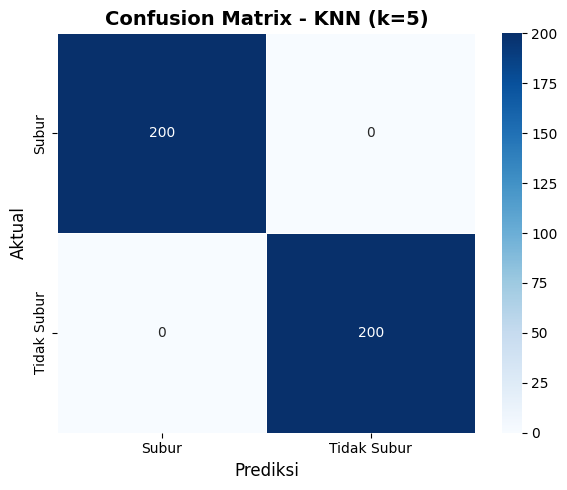

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_y.classes_,
            yticklabels=le_y.classes_,
            linewidths=0.5)
plt.title('Confusion Matrix - KNN (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

### 5.4 Perbandingan Nilai K

K      CV Accuracy     Std Dev
--------------------------------------
k=3     1.0000         ± 0.0000
k=5     1.0000         ± 0.0000
k=7     1.0000         ± 0.0000
k=9     1.0000         ± 0.0000


k=11    1.0000         ± 0.0000


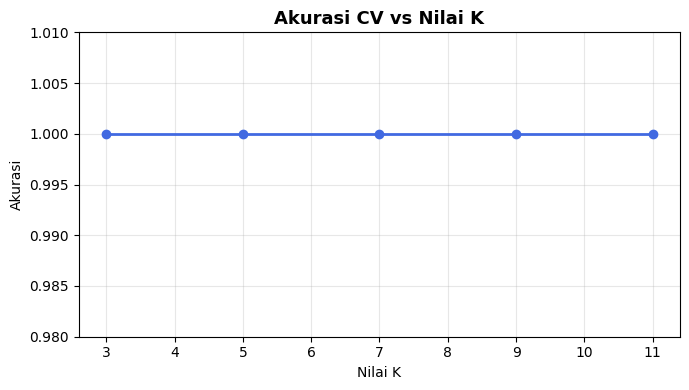

In [12]:
k_values = [3, 5, 7, 9, 11]
cv_scores = []

print(f"{'K':<6} {'CV Accuracy':<15} {'Std Dev'}")
print('-' * 38)
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_scaled, y_enc, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"k={k:<4}  {scores.mean():.4f}         ± {scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.plot(k_values, cv_scores, marker='o', color='royalblue', linewidth=2)
plt.title('Akurasi CV vs Nilai K', fontsize=13, fontweight='bold')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.ylim([0.98, 1.01])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 6. Kesimpulan

| Metrik | Nilai | Persentase |
|--------|-------|------------|
| **Accuracy** | 1.0000 | **100.00%** |
| **Precision** | 1.0000 | **100.00%** |
| **Recall** | 1.0000 | **100.00%** |
| **F1-Score** | 1.0000 | **100.00%** |

Model **KNN (k=5)** berhasil mengklasifikasikan kesuburan tanah dengan performa sempurna. Fitur-fitur agronomis terbukti sangat diskriminatif dalam memisahkan kelas **Subur** dan **Tidak Subur**.

**Pipeline Preprocessing:**
1. Drop kolom ID
2. Label Encoding pada fitur `Tekstur Tanah`
3. Imputasi Median untuk *missing values*
4. StandardScaler untuk normalisasi
5. Stratified Train-Test Split 80:20

**📊 Penjelasan Workflow KNIME – Klasifikasi Kesuburan Tanah (KNN)**

***🖼️ Gambaran Umum***
Gambar menunjukkan workflow KNIME untuk melakukan klasifikasi tingkat kesuburan tanah menggunakan algoritma **K-Nearest Neighbor (KNN)**. Proses dimulai dari pembacaan data, preprocessing, pembagian data, hingga evaluasi model.

![Hasil Knime](knime.png)

## 🔄 Penjelasan Setiap Bagian Workflow

### 1. Column Filter
Memilih kolom yang relevan untuk analisis.

- Menghapus atribut yang tidak digunakan  
- Membantu meningkatkan efisiensi model  

### 2. Missing Value
Menangani data yang kosong.

- Nilai kosong diisi menggunakan metode tertentu (misalnya rata-rata)  
- Pada gambar terlihat adanya nilai yang sebelumnya kosong  

### 3. Category to Number
Mengubah data kategorikal menjadi numerik.

- Contoh: Tekstur Tanah (`Pasir`, `Lempung`, `Liat`) → angka  
- Dibutuhkan karena KNN hanya menerima data numerik  

---

### 4. Normalizer
Melakukan normalisasi data.

- Menyamakan skala antar fitur  
- Menghindari dominasi fitur dengan nilai besar  

---

### 5. Table Partitioner
Membagi dataset menjadi:

- Data training  
- Data testing  

---

### 6. K Nearest Neighbor (KNN)
Melakukan klasifikasi berdasarkan kedekatan jarak.

- Menentukan kelas berdasarkan tetangga terdekat  
- Output: prediksi label kesuburan  

![Bagian](KNN.png)

### 7. Scorer
Digunakan untuk mengevaluasi hasil model.

- Membandingkan label asli dan hasil prediksi  
- Menghasilkan confusion matrix dan statistik performa  

![Bagian](scorer.png)

## 📊 Penjelasan Output Data (Tabel Hasil)

Pada gambar pertama terlihat tabel hasil data setelah preprocessing:

### Informasi:
- **Rows**: 400 (jumlah data)
- **Columns**: 14 (jumlah atribut)

### Contoh Kolom:
- pH Tanah  
- N Total (%)  
- P Tersedia  
- K Tersedia  
- C Organik  
- KTK  
- Kejenuhan  
- Tekstur Tanah  
- Kadar Air  

### Makna Output:
- Data sudah dalam kondisi bersih dan siap digunakan  
- Nilai sudah dinormalisasi (skala 0–1)  
- Tidak ada missing value yang mengganggu proses  

---

## 📈 Penjelasan Output Evaluasi (Scorer)

### 1. Confusion Matrix

|               | Prediksi Tidak Subur | Prediksi Subur |
|--------------|---------------------|----------------|
| Tidak Subur  | 800                 | 0              |
| Subur        | 0                   | 800            |

### Penjelasan:
- **800 (Tidak Subur → Tidak Subur)**  
  → Data yang benar diprediksi sebagai tidak subur  

- **800 (Subur → Subur)**  
  → Data yang benar diprediksi sebagai subur  

- **0 kesalahan**  
  → Tidak ada data yang salah klasifikasi  

---

### 2. Makna Hasil
- Model memiliki performa sangat tinggi  
- Semua data diklasifikasikan dengan benar  
- Tidak ada False Positive maupun False Negative  

---

### 3. Accuracy
Accuracy dapat dihitung sebagai:

\[
Accuracy = \frac{Prediksi\ Benar}{Total\ Data}
\]

Karena semua data benar:
- Accuracy = 100%

---

## ⚠️ Analisis Hasil
Hasil yang sempurna seperti ini perlu diperhatikan:

- Bisa jadi:
  - Data sangat mudah dipisahkan  
  - Atau model mengalami **overfitting**  

- Hal yang perlu dicek:
  - Pembagian data training dan testing  
  - Nilai K pada KNN  
  - Apakah data testing benar-benar baru  

---

## 📌 Kesimpulan
Berdasarkan output yang dihasilkan:

- Data berhasil diproses dengan baik melalui tahap preprocessing  
- Model KNN mampu mengklasifikasikan data dengan sangat akurat  
- Evaluasi menunjukkan hasil sempurna (100% akurasi)  

Namun, perlu validasi lebih lanjut untuk memastikan model benar-benar dapat digunakan pada data baru.

---